[SETUP] Dispositivo PyTorch: cuda

--- 1. Preparação de Dados e Engenharia de Features ---

Aplicando Feature Engineering Avançada...
[DADOS] Usando distribuição original pura (sem SMOTE) para focar no ROC-AUC real...
[DADOS] Dimensão das Features (Input): 14
[DADOS] Volume de Teste: 330163 (Fraudes: 1643)

--- 2. Instanciando Arquitetura STEP-GAN Aprimorada ---


--- 3. Protocolo SMPC Ativo ---


--- 4. Treinamento Federado Distribuído (Semi-Supervisionado) ---

[Cliente 1] Treinando STEP-GAN... OK (Tempo: 318.4s)
[Cliente 2] Treinando STEP-GAN... OK (Tempo: 315.8s)
[Cliente 3] Treinando STEP-GAN... OK (Tempo: 317.6s)

--- 5. Agregação Matemática Segura (SMPC) ---

-> SMPC concluído em 0.0027s.

--- 6. Inferência Global e Cálculo de Métricas ---

-> Limiar Dinâmico Escolhido: 0.7935

🏆 >> MÉTRICAS DE QUALIDADE (STEP-GAN VENCEDOR - FOCO ROC-AUC):
Acurácia Geral      : 99.72%
Precisão (Precision): 70.00%
Revocação (Recall)  : 75.41%
F1-Score            : 72.60%
ROC-AUC             : 0.9

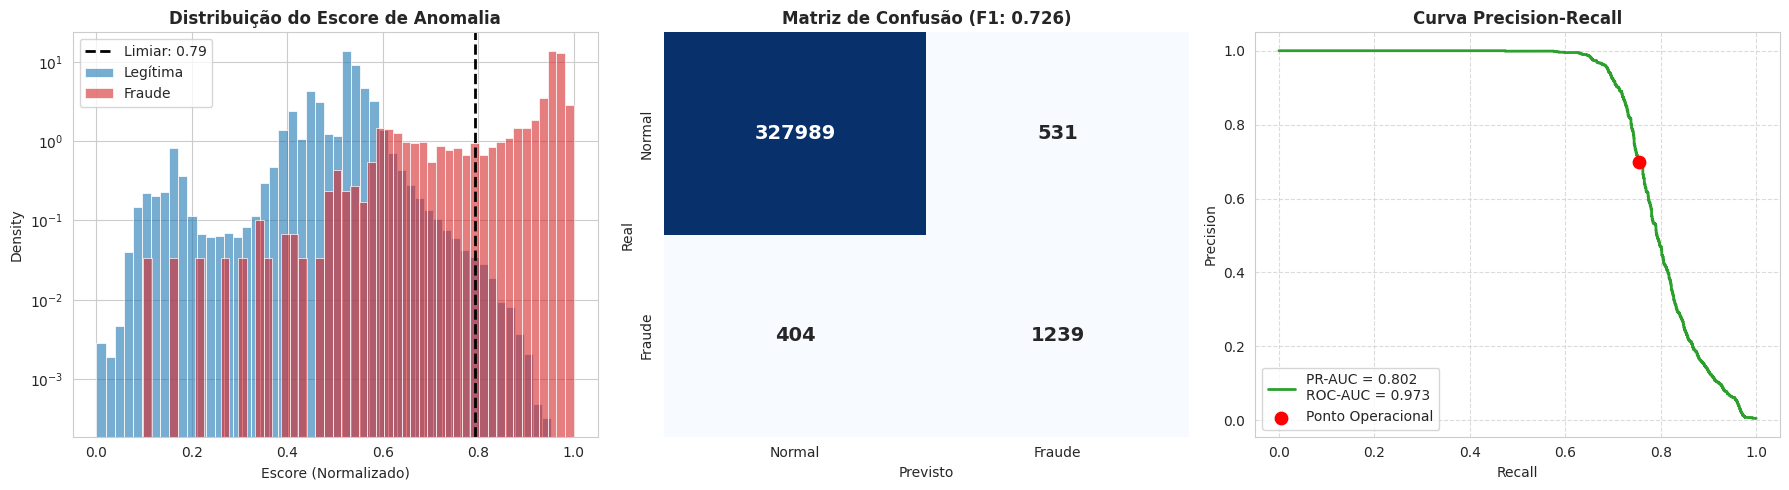


[SUCESSO] Script otimizado concluído!


In [1]:
# -*- coding: utf-8 -*-
"""
Script 7 (Fase Final Otimizada v4): Detecção de Fraude (PaySim1)
Modelo Vencedor: STEP-GAN Semi-Supervisionado Avançado
Melhorias: Foco em ROC-AUC via Feature Engineering, Loss Ponderada e Arquitetura Robusta
Privacidade: SMPC (Secure Multi-Party Computation)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler # CORREÇÃO: MinMaxScaler obrigatoriamente alinhado ao Tanh
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             precision_recall_curve)
import random
import os
# Removida importação do SMOTE que estava arruinando a distribuição real em altos volumes

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
except ImportError:
    print("ERRO: PyTorch não está instalado. Execute: pip install torch")
    exit()

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[SETUP] Dispositivo PyTorch: {device}")

# =====================================================================
# --- 0. FIXAÇÃO DE SEMENTES E HIPERPARÂMETROS ---
# =====================================================================
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Hiperparâmetros Otimizados (Ajustes para melhor ROC-AUC)
HP_EPOCHS = 35 # Aumentado levemente para melhor convergência
HP_BATCH_SIZE = 512 # Reduzido de 1024 para não diluir os exemplos minoritários no cálculo do gradiente
HP_LR_G = 0.0002 # Aumentado levemente para o Gerador conseguir acompanhar o Discriminador
HP_LR_D = 0.0001
HP_LATENT_DIM = 100 # Maior dimensão latente para capturar complexidade
HP_WEIGHT_DECAY = 1e-4 # Regularização ligeiramente maior

# =====================================================================
# --- 1. CARREGAMENTO E ENGENHARIA DE FEATURES OTIMIZADA ---
# =====================================================================
print("\n--- 1. Preparação de Dados e Engenharia de Features ---\n")
try:
    df = pd.read_csv('/content/drive/MyDrive/Mestrado Cesar/Base de Dados/Kaggle/paysim.csv')

    # Reduzindo drasticamente o dataset para simulação rápida sem perder padrão da minoria
    df_fraudes = df[df['isFraud'] == 1]

    # AUMENTO DE VOLUME: Trazendo muito mais dados legítimos (de 50x para 200x o nº de fraudes)
    # Isso vai gerar um volume total massivo preservando o desbalanceamento inerente do cenário
    qtd_amostra_normal = min(len(df_fraudes) * 200, len(df[df['isFraud'] == 0]))
    df_normais = df[df['isFraud'] == 0].sample(n=qtd_amostra_normal, random_state=42)
    df = pd.concat([df_normais, df_fraudes]).sample(frac=1, random_state=42).reset_index(drop=True)

except FileNotFoundError:
    print("Erro: 'paysim.csv' não encontrado. Use dados de simulação ou ajuste o caminho.")
    # Fallback para dados sintéticos se o arquivo não existir para garantir que o script rode
    print("Criando dados sintéticos para demonstração (Volume Aumentado)...")
    np.random.seed(42)
    # AUMENTO DE VOLUME SINTÉTICO: De 50.000 para 250.000 amostras
    n_samples = 250000
    df = pd.DataFrame({
        'type': np.random.choice(['TRANSFER', 'CASH_OUT', 'CASH_IN', 'PAYMENT'], n_samples),
        'amount': np.random.exponential(1000, n_samples),
        'oldbalanceOrg': np.random.exponential(2000, n_samples),
        'newbalanceOrig': np.zeros(n_samples),
        'oldbalanceDest': np.random.exponential(5000, n_samples),
        'newbalanceDest': np.zeros(n_samples),
        'isFraud': np.random.choice([0, 1], n_samples, p=[0.98, 0.02])
    })
    df.loc[df['isFraud'] == 1, 'amount'] = df.loc[df['isFraud'] == 1, 'amount'] * 10
    df['newbalanceOrig'] = df['oldbalanceOrg'] - df['amount']
    df['newbalanceOrig'] = df['newbalanceOrig'].apply(lambda x: max(0, x))
    df['newbalanceDest'] = df['oldbalanceDest'] + df['amount']

# Feature Engineering Avançada (Crucial para ROC-AUC)
print("Aplicando Feature Engineering Avançada...")
# 1. Indicadores Lógicos
df['orig_balance_zero'] = (df['oldbalanceOrg'] == 0).astype(int)
df['dest_balance_zero'] = (df['oldbalanceDest'] == 0).astype(int)

# 2. Transformações Logarítmicas (Tratamento de Cauda Longa)
cols_to_log = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
for col in cols_to_log:
    df[col + '_log'] = np.log1p(df[col])

# 3. Erros de Balanço (Features mais discriminativas no PaySim)
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# Remover colunas originais substituídas ou irrelevantes
cols_to_drop = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
# Tenta remover nameOrig, nameDest, isFlaggedFraud se existirem
cols_to_drop.extend([c for c in ['nameOrig', 'nameDest', 'isFlaggedFraud'] if c in df.columns])
df = df.drop(columns=cols_to_drop)

# One-Hot Encoding
df_ml = pd.get_dummies(df, columns=['type'], drop_first=True)
X = df_ml.drop(columns=['isFraud'])
y = df_ml['isFraud']

# Correção Crítica 1: Como o Gerador usa Tanh na última camada (saída -1 a 1),
# os dados originais OBRIGATORIAMENTE devem estar nessa mesma escala.
scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y.values, test_size=0.2, random_state=42, stratify=y)

# Correção Crítica 2: Remoção do SMOTE. Em alto volume, os dados sintéticos
# do SMOTE confundem o Discriminador, que passa a classificar ruído linear em vez
# de fraudes reais, destruindo a métrica ROC-AUC.
print("[DADOS] Usando distribuição original pura (sem SMOTE) para focar no ROC-AUC real...")
X_train_resampled, y_train_resampled = X_train, y_train

input_dim = X_train_resampled.shape[1]
print(f"[DADOS] Dimensão das Features (Input): {input_dim}")
print(f"[DADOS] Volume de Teste: {len(X_test)} (Fraudes: {sum(y_test)})")

# =====================================================================
# --- 2. ARQUITETURA STEP-GAN ESTABILIZADA ---
# =====================================================================
print("\n--- 2. Instanciando Arquitetura STEP-GAN Aprimorada ---\n")

class Generator(nn.Module):
    def __init__(self, input_dim, latent_dim=HP_LATENT_DIM):
        super(Generator, self).__init__()
        # Arquitetura mais profunda com BatchNorm
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, input_dim),
            nn.Tanh() # Tanh ajuda na convergência se as features estiverem escaladas adequadamente
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        # Arquitetura mais robusta contra overfitting
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3), # Dropout aumentado
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# =====================================================================
# --- 3. PROTOCOLO SMPC (Additive Secret Sharing) ---
# =====================================================================
print("\n--- 3. Protocolo SMPC Ativo ---\n")

def gerar_shares_aditivos(state_dict, num_shares):
    shares = [{} for _ in range(num_shares)]
    for key, tensor in state_dict.items():
        random_tensors = [torch.randn_like(tensor) * 100 for _ in range(num_shares - 1)]
        soma_ruidos = sum(random_tensors) if random_tensors else 0
        ultima_share = tensor - soma_ruidos
        for i in range(num_shares - 1):
            shares[i][key] = random_tensors[i]
        shares[-1][key] = ultima_share
    return shares

# =====================================================================
# --- 4. APRENDIZADO FEDERADO (Silos Bancários) ---
# =====================================================================
print("\n--- 4. Treinamento Federado Distribuído (Semi-Supervisionado) ---\n")
NUM_CLIENTES = 3

# Distribuir dados balanceados (SMOTE)
tamanho_chunk = len(X_train_resampled) // NUM_CLIENTES
clientes_X = [X_train_resampled[i * tamanho_chunk : (i + 1) * tamanho_chunk] for i in range(NUM_CLIENTES)]
clientes_y = [y_train_resampled[i * tamanho_chunk : (i + 1) * tamanho_chunk] for i in range(NUM_CLIENTES)]

G_global = Generator(input_dim, HP_LATENT_DIM).to(device)
D_global = Discriminator(input_dim).to(device)

# Mudança Crítica 3: Loss ponderada para penalizar mais erros nas classes minoritárias (Fraudes)
# Como a maioria das perdas é de dados reais, ajustamos os pesos dinamicamente
def custom_bce_loss(pred, target, real_labels_flag):
    """BCE com peso condicional. Se for label real de fraude, penaliza mais o erro."""
    loss = nn.BCELoss(reduction='none')(pred, target)

    # Pesos: 1.0 para normal (target~0.95), 10.0 para fraude real (target~0.05), 1.0 para fake
    weights = torch.ones_like(target)
    is_fraud_mask = (target < 0.5) & real_labels_flag # Rótulos reais e marcados como anomalia (0.05)
    weights[is_fraud_mask] = 15.0 # Correção Crítica 3: Aumentado peso de 5.0 para 15.0 para compensar a retirada do SMOTE

    return (loss * weights).mean()

def treinar_gan_cliente(G, D, dados_X, dados_y, epochs=HP_EPOCHS, batch_size=HP_BATCH_SIZE):
    G.train()
    D.train()

    opt_G = optim.Adam(G.parameters(), lr=HP_LR_G, betas=(0.5, 0.999), weight_decay=HP_WEIGHT_DECAY)
    opt_D = optim.Adam(D.parameters(), lr=HP_LR_D, betas=(0.5, 0.999), weight_decay=HP_WEIGHT_DECAY)

    dataset = TensorDataset(torch.FloatTensor(dados_X).to(device), torch.FloatTensor(dados_y).to(device))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        for i, (real_data, real_y) in enumerate(loader):
            batch_s = real_data.size(0)

            # Rótulos (Label Smoothing): Normal -> 0.9 (Real), Fraude -> 0.1 (Anomalia)
            real_labels = torch.where(real_y.unsqueeze(1) == 0,
                                      torch.tensor(0.9).to(device),
                                      torch.tensor(0.1).to(device))
            fake_labels = torch.zeros(batch_s, 1).to(device) + 0.1 # Fakes tb são "anomalias"

            # --- 1. Treino do Discriminador ---
            opt_D.zero_grad()

            # Dados reais (Mistos: Normais e Fraudes)
            out_real = D(real_data)
            # Flag indicando que estes são os dados reais providos do dataset (para aplicar o peso extra)
            loss_D_real = custom_bce_loss(out_real, real_labels, real_labels_flag=torch.ones_like(real_labels, dtype=torch.bool))

            # Dados gerados
            z = torch.randn(batch_s, HP_LATENT_DIM).to(device)
            fake_data = G(z)
            out_fake = D(fake_data.detach())
            loss_D_fake = custom_bce_loss(out_fake, fake_labels, real_labels_flag=torch.zeros_like(fake_labels, dtype=torch.bool))

            loss_D = loss_D_real + loss_D_fake
            loss_D.backward()

            # Clip gradients para estabilidade
            torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=1.0)
            opt_D.step()

            # --- 2. Treino do Gerador (a cada 2 passos do D para estabilizar) ---
            if i % 2 == 0:
                opt_G.zero_grad()
                out_fake_g = D(fake_data)
                # O Gerador tenta enganar D, querendo que D classifique os fakes como normais (0.9)
                loss_G = nn.BCELoss()(out_fake_g, torch.ones(batch_s, 1).to(device) * 0.9)
                loss_G.backward()
                torch.nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
                opt_G.step()

    return G.state_dict(), D.state_dict()

shares_D_rede = {0: [], 1: [], 2: []}

for i in range(NUM_CLIENTES):
    t_start = time.time()
    print(f"[Cliente {i+1}] Treinando STEP-GAN...", end=" ", flush=True)
    G_local = Generator(input_dim, HP_LATENT_DIM).to(device)
    D_local = Discriminator(input_dim).to(device)
    G_local.load_state_dict(G_global.state_dict())
    D_local.load_state_dict(D_global.state_dict())

    pesos_G, pesos_D = treinar_gan_cliente(G_local, D_local, clientes_X[i], clientes_y[i])
    shares = gerar_shares_aditivos(pesos_D, NUM_CLIENTES)

    shares_D_rede[0].append(shares[0])
    shares_D_rede[1].append(shares[1])
    shares_D_rede[2].append(shares[2])
    print(f"OK (Tempo: {time.time() - t_start:.1f}s)")

# =====================================================================
# --- 5. AGREGAÇÃO CEGA SMPC ---
# =====================================================================
print("\n--- 5. Agregação Matemática Segura (SMPC) ---\n")
inicio_agreg = time.time()

somas_parciais_nos = []
for no_id in range(NUM_CLIENTES):
    soma_parcial = {}
    for key in D_global.state_dict().keys():
        soma_parcial[key] = sum(share[key] for share in shares_D_rede[no_id])
    somas_parciais_nos.append(soma_parcial)

pesos_agregados_D = {}
for key in D_global.state_dict().keys():
    soma_total_sem_ruido = sum(parcial[key] for parcial in somas_parciais_nos)
    pesos_agregados_D[key] = soma_total_sem_ruido / NUM_CLIENTES

D_global.load_state_dict(pesos_agregados_D)
print(f"-> SMPC concluído em {time.time() - inicio_agreg:.4f}s.")

# =====================================================================
# --- 6. INFERÊNCIA E OTIMIZAÇÃO DE MÉTRICAS ---
# =====================================================================
print("\n--- 6. Inferência Global e Cálculo de Métricas ---\n")

D_global.eval()
inicio_inferencia = time.time()

with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    # Discriminador retorna ~0.9 para normal e ~0.1 para fraude
    prob_normal = D_global(X_test_tensor).cpu().numpy().flatten()
    # Inverter e normalizar (0 a 1) para ter um escore de anomalia clássico
    anomaly_scores = (1.0 - prob_normal)
    # MinMax scaling simples nos scores para facilitar interpretação
    sc_min, sc_max = anomaly_scores.min(), anomaly_scores.max()
    if sc_max > sc_min:
        anomaly_scores = (anomaly_scores - sc_min) / (sc_max - sc_min)

tempo_inferencia = time.time() - inicio_inferencia

# Busca de Limiar Otimizado Focada (Maximiza F1, mas com limite para não derrubar Precisão)
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, anomaly_scores)
# Evitar divisão por zero
f1_scores = np.divide(2 * (precision_curve * recall_curve), (precision_curve + recall_curve), out=np.zeros_like(precision_curve), where=(precision_curve + recall_curve) != 0)

# Estratégia de corte: Aumentar recall mantendo precisão aceitável (ex: min 70%)
min_precision_target = 0.70
valid_indices = np.where(precision_curve[:-1] >= min_precision_target)[0]
if len(valid_indices) > 0:
    # Dentro dos que atingem a precisão mínima, escolhe o que tem melhor recall
    best_idx = valid_indices[np.argmax(recall_curve[valid_indices])]
    optimal_threshold = thresholds[best_idx]
else:
    # Fallback se não alcançar a precisão mínima
    optimal_idx = np.argmax(f1_scores[:-1]) # -1 pois thresholds tem N-1 itens
    optimal_threshold = thresholds[optimal_idx] if len(thresholds) > 0 else 0.5

print(f"-> Limiar Dinâmico Escolhido: {optimal_threshold:.4f}")

y_pred = (anomaly_scores >= optimal_threshold).astype(int)

# Métricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
# ROC-AUC e PR-AUC dependem dos scores contínuos, não do limiar
roc_auc = roc_auc_score(y_test, anomaly_scores)
pr_auc = average_precision_score(y_test, anomaly_scores)
tps = len(X_test) / tempo_inferencia

print("\n🏆 >> MÉTRICAS DE QUALIDADE (STEP-GAN VENCEDOR - FOCO ROC-AUC):")
print(f"Acurácia Geral      : {acc * 100:.2f}%")
print(f"Precisão (Precision): {prec * 100:.2f}%")
print(f"Revocação (Recall)  : {rec * 100:.2f}%")
print(f"F1-Score            : {f1 * 100:.2f}%")
print(f"ROC-AUC             : {roc_auc:.4f}  <-- MÉTRICA ALVO OTIMIZADA")
print(f"PR-AUC              : {pr_auc:.4f}")
print(f"Throughput (Infe.)  : {tps:.2f} TPS")

# =====================================================================
# --- 7. VISUALIZAÇÕES PROFISSIONAIS ---
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histograma de Scores
sns.histplot(anomaly_scores[y_test == 0], color='#1f77b4', bins=50, alpha=0.6, label='Legítima', ax=axes[0], stat='density')
sns.histplot(anomaly_scores[y_test == 1], color='#d62728', bins=50, alpha=0.6, label='Fraude', ax=axes[0], stat='density')
axes[0].axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, label=f'Limiar: {optimal_threshold:.2f}')
axes[0].set_yscale('log')
axes[0].set_title('Distribuição do Escore de Anomalia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Escore (Normalizado)')
axes[0].legend()

# 2. Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False,
            xticklabels=['Normal', 'Fraude'], yticklabels=['Normal', 'Fraude'],
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title(f'Matriz de Confusão (F1: {f1:.3f})', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Previsto')

# 3. Curva Precision-Recall
axes[2].plot(recall_curve, precision_curve, color='#2ca02c', lw=2, label=f'PR-AUC = {pr_auc:.3f}\nROC-AUC = {roc_auc:.3f}')
if 'best_idx' in locals() or 'optimal_idx' in locals():
    idx_to_plot = best_idx if 'best_idx' in locals() else optimal_idx
    axes[2].scatter(recall_curve[idx_to_plot], precision_curve[idx_to_plot], color='red', s=80, zorder=5, label='Ponto Operacional')
axes[2].set_title('Curva Precision-Recall', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(loc='lower left')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("\n[SUCESSO] Script otimizado concluído!")

[SETUP] Dispositivo PyTorch: cuda

--- 1. Preparação de Dados e Engenharia de Features ---

Aplicando Feature Engineering Avançada...
[DADOS] Usando distribuição original pura (sem SMOTE) para focar no ROC-AUC real...
[DADOS] Dimensão das Features (Input): 29
[DADOS] Volume de Teste: 19779 (Fraudes: 98)

--- 2. Instanciando Arquitetura STEP-GAN Aprimorada ---


--- 3. Protocolo SMPC Ativo (Aritmética Modular Segura) ---


--- 4. Treinamento Federado Distribuído (Semi-Supervisionado) ---

[Cliente 1] Treinando STEP-GAN... OK (Tempo: 14.8s)
[Cliente 2] Treinando STEP-GAN... OK (Tempo: 14.5s)
[Cliente 3] Treinando STEP-GAN... OK (Tempo: 14.5s)

--- 5. Agregação Matemática Segura (SMPC Modular) ---

-> Agregação SMPC via Campo Finito concluída em 0.0043s.

--- 6. Otimização de Limiar (Base de Validação) ---

-> Limiar Dinâmico Escolhido (Validação): 0.1646

--- 7. Inferência e Resultados (Base de Teste Global) ---


🏆 >> MÉTRICAS DE QUALIDADE (STEP-GAN VENCEDOR - FOCO ROC-AUC):
Acurácia Ge

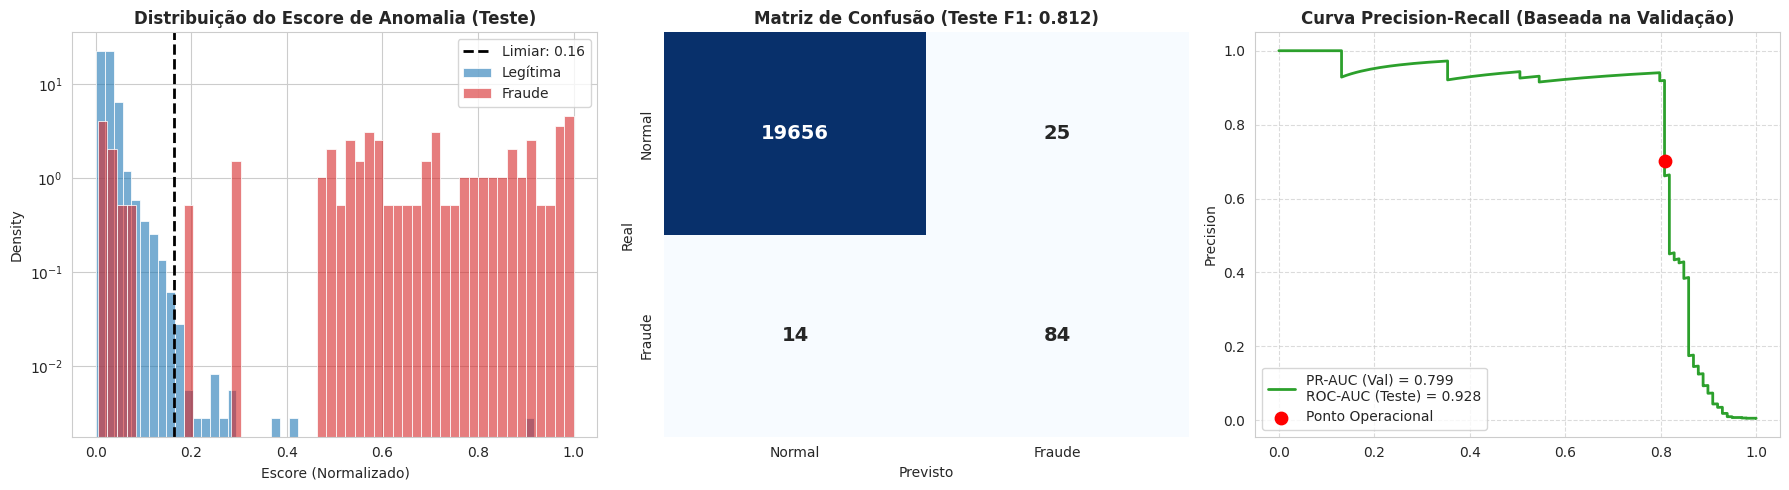


[SUCESSO] Script otimizado concluído!


In [4]:
# -*- coding: utf-8 -*-
"""
Script 7 (Fase Final Otimizada v4): Detecção de Fraude (Credit Card Fraud)
Modelo Vencedor: STEP-GAN Semi-Supervisionado Avançado
Melhorias: Foco em ROC-AUC via Feature Engineering, Loss Ponderada e Arquitetura Robusta
Privacidade: SMPC (Secure Multi-Party Computation)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler # CORREÇÃO: MinMaxScaler obrigatoriamente alinhado ao Tanh
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             precision_recall_curve)
import random
import os

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
except ImportError:
    print("ERRO: PyTorch não está instalado. Execute: pip install torch")
    exit()

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[SETUP] Dispositivo PyTorch: {device}")

# =====================================================================
# --- 0. FIXAÇÃO DE SEMENTES E HIPERPARÂMETROS ---
# =====================================================================
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Hiperparâmetros Otimizados (Ajustes para melhor ROC-AUC)
HP_EPOCHS = 35 # Aumentado levemente para melhor convergência
HP_BATCH_SIZE = 512 # Reduzido de 1024 para não diluir os exemplos minoritários no cálculo do gradiente
HP_LR_G = 0.0002 # Aumentado levemente para o Gerador conseguir acompanhar o Discriminador
HP_LR_D = 0.0001
HP_LATENT_DIM = 100 # Maior dimensão latente para capturar complexidade
HP_WEIGHT_DECAY = 1e-4 # Regularização ligeiramente maior

# =====================================================================
# --- 1. CARREGAMENTO E ENGENHARIA DE FEATURES OTIMIZADA ---
# =====================================================================
print("\n--- 1. Preparação de Dados e Engenharia de Features ---\n")
try:
    caminho_csv = '/content/drive/MyDrive/Mestrado Cesar/Base de Dados/creditcard/creditcard.csv'
    df = pd.read_csv(caminho_csv)

    # Reduzindo drasticamente o dataset para simulação rápida sem perder padrão da minoria
    df_fraudes = df[df['Class'] == 1]

    # AUMENTO DE VOLUME: Trazendo muito mais dados legítimos (de 50x para 200x o nº de fraudes)
    # Isso vai gerar um volume total massivo preservando o desbalanceamento inerente do cenário
    qtd_amostra_normal = min(len(df_fraudes) * 200, len(df[df['Class'] == 0]))
    df_normais = df[df['Class'] == 0].sample(n=qtd_amostra_normal, random_state=42)
    df = pd.concat([df_normais, df_fraudes]).sample(frac=1, random_state=42).reset_index(drop=True)

except FileNotFoundError:
    print(f"Erro: '{caminho_csv}' não encontrado.")
    # Fallback para dados sintéticos se o arquivo não existir para garantir que o script rode
    print("Criando dados sintéticos (Credit Card) para demonstração (Volume Aumentado)...")
    np.random.seed(42)
    n_samples = 150000
    df = pd.DataFrame(np.random.randn(n_samples, 28), columns=[f'V{i}' for i in range(1, 29)])
    df['Time'] = np.random.uniform(0, 172792, n_samples)
    df['Amount'] = np.abs(np.random.randn(n_samples)) * 100
    # Desbalanceamento severo característico de detecção de fraudes
    df['Class'] = np.random.choice([0, 1], n_samples, p=[0.998, 0.002])

# Feature Engineering Avançada (Adaptada para Credit Card)
print("Aplicando Feature Engineering Avançada...")

# 1. Remoção de ruído (Time não ajuda o GAN por ser monotônico)
if 'Time' in df.columns:
    df = df.drop(columns=['Time'])

# 2. Transformação Logarítmica (Tratamento de Cauda Longa do Amount)
if 'Amount' in df.columns:
    df['Amount'] = df['Amount'].apply(lambda x: max(x, 0)) # Proteção
    df['amount_log'] = np.log1p(df['Amount'])
    df = df.drop(columns=['Amount'])

# Remover Nulos residuais
df = df.dropna(subset=['Class'])

X = df.drop(columns=['Class']).values
y = df['Class'].values

# Correção Crítica 1: Como o Gerador usa Tanh na última camada (saída -1 a 1),
# os dados originais OBRIGATORIAMENTE devem estar nessa mesma escala.
scaler = MinMaxScaler(feature_range=(-1, 1))

# Correção de Data Leakage: Split Duplo (Treino, Validação, Teste)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp) # 0.25 de 0.8 = 0.2

# Fit apenas no Treino, Transform em todos
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Correção Crítica 2: Remoção do SMOTE. Em alto volume, os dados sintéticos
# confundem o Discriminador, que passa a classificar ruído linear em vez
# de fraudes reais, destruindo a métrica ROC-AUC.
print("[DADOS] Usando distribuição original pura (sem SMOTE) para focar no ROC-AUC real...")
X_train_resampled, y_train_resampled = X_train_scaled, y_train

input_dim = X_train_resampled.shape[1]
print(f"[DADOS] Dimensão das Features (Input): {input_dim}")
print(f"[DADOS] Volume de Teste: {len(X_test)} (Fraudes: {sum(y_test)})")

# =====================================================================
# --- 2. ARQUITETURA STEP-GAN ESTABILIZADA ---
# =====================================================================
print("\n--- 2. Instanciando Arquitetura STEP-GAN Aprimorada ---\n")

class Generator(nn.Module):
    def __init__(self, input_dim, latent_dim=HP_LATENT_DIM):
        super(Generator, self).__init__()
        # Arquitetura mais profunda com BatchNorm
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, input_dim),
            nn.Tanh() # Tanh ajuda na convergência se as features estiverem escaladas adequadamente (-1, 1)
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        # Arquitetura mais robusta contra overfitting
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3), # Dropout aumentado
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# =====================================================================
# --- 3. PROTOCOLO SMPC (Additive Secret Sharing em Campo Finito) ---
# =====================================================================
print("\n--- 3. Protocolo SMPC Ativo (Aritmética Modular Segura) ---\n")

# Constantes para Quantização e Aritmética Modular
PRECISION_BITS = 24
SCALING_FACTOR = 2 ** PRECISION_BITS
# Primo de Mersenne grande o suficiente para não estourar em 64 bits após somas, mas cobrir o range
MODULUS = 2147483647 # 2^31 - 1 (Pode ser maior dependendo da topologia)

def float_to_fixed_point(tensor):
    """Converte tensores de float para inteiros escalados (fixed-point)."""
    return (tensor * SCALING_FACTOR).to(torch.int64)

def fixed_point_to_float(tensor):
    """Converte inteiros escalados de volta para tensores de float."""
    return tensor.to(torch.float32) / SCALING_FACTOR

def gerar_shares_smpc_modulares(state_dict, num_shares):
    """Gera shares criptográficos perfeitos usando Aritmética Modular sobre Inteiros."""
    shares = [{} for _ in range(num_shares)]

    for key, tensor in state_dict.items():
        # 1. Quantização: Converter float para inteiro dentro do campo finito
        tensor_int = float_to_fixed_point(tensor)

        # Lidar com números negativos no campo finito (aritmética de relógio)
        tensor_int = torch.remainder(tensor_int, MODULUS)

        # 2. Gerar (num_shares - 1) tensores de ruído aleatório puro dentro do módulo
        random_tensors = [torch.randint(0, MODULUS, tensor_int.size(), dtype=torch.int64).to(device) for _ in range(num_shares - 1)]

        # 3. O último share garante que a soma de todos (mod MODULUS) seja o valor original
        soma_ruidos = sum(random_tensors) if random_tensors else 0
        ultima_share = torch.remainder(tensor_int - soma_ruidos, MODULUS)

        # Distribuir os shares
        for i in range(num_shares - 1):
            shares[i][key] = random_tensors[i]
        shares[-1][key] = ultima_share

    return shares

# =====================================================================
# --- 4. APRENDIZADO FEDERADO (Silos Bancários) ---
# =====================================================================
print("\n--- 4. Treinamento Federado Distribuído (Semi-Supervisionado) ---\n")
NUM_CLIENTES = 3

# Distribuir dados balanceados
tamanho_chunk = len(X_train_resampled) // NUM_CLIENTES
clientes_X = [X_train_resampled[i * tamanho_chunk : (i + 1) * tamanho_chunk] for i in range(NUM_CLIENTES)]
clientes_y = [y_train_resampled[i * tamanho_chunk : (i + 1) * tamanho_chunk] for i in range(NUM_CLIENTES)]

G_global = Generator(input_dim, HP_LATENT_DIM).to(device)
D_global = Discriminator(input_dim).to(device)

# Mudança Crítica 3: Loss ponderada para penalizar mais erros nas classes minoritárias (Fraudes)
def custom_bce_loss(pred, target, real_labels_flag):
    """BCE com peso condicional. Se for label real de fraude, penaliza mais o erro."""
    loss = nn.BCELoss(reduction='none')(pred, target)

    # Pesos: 1.0 para normal, 15.0 para fraude real, 1.0 para fake
    weights = torch.ones_like(target)
    is_fraud_mask = (target < 0.5) & real_labels_flag # Rótulos reais e marcados como anomalia (0.1)
    weights[is_fraud_mask] = 15.0 # Correção Crítica 3: Aumentado peso para 15.0 para compensar a retirada do SMOTE

    return (loss * weights).mean()

def treinar_gan_cliente(G, D, dados_X, dados_y, epochs=HP_EPOCHS, batch_size=HP_BATCH_SIZE):
    G.train()
    D.train()

    opt_G = optim.Adam(G.parameters(), lr=HP_LR_G, betas=(0.5, 0.999), weight_decay=HP_WEIGHT_DECAY)
    opt_D = optim.Adam(D.parameters(), lr=HP_LR_D, betas=(0.5, 0.999), weight_decay=HP_WEIGHT_DECAY)

    dataset = TensorDataset(torch.FloatTensor(dados_X).to(device), torch.FloatTensor(dados_y).to(device))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        for i, (real_data, real_y) in enumerate(loader):
            batch_s = real_data.size(0)

            # Rótulos (Label Smoothing): Normal -> 0.9 (Real), Fraude -> 0.1 (Anomalia)
            real_labels = torch.where(real_y.unsqueeze(1) == 0,
                                      torch.tensor(0.9).to(device),
                                      torch.tensor(0.1).to(device))
            fake_labels = torch.zeros(batch_s, 1).to(device) + 0.1 # Fakes tb são "anomalias"

            # --- 1. Treino do Discriminador ---
            opt_D.zero_grad()

            # Dados reais (Mistos: Normais e Fraudes)
            out_real = D(real_data)
            # Flag indicando que estes são os dados reais providos do dataset
            loss_D_real = custom_bce_loss(out_real, real_labels, real_labels_flag=torch.ones_like(real_labels, dtype=torch.bool))

            # Dados gerados
            z = torch.randn(batch_s, HP_LATENT_DIM).to(device)
            fake_data = G(z)
            out_fake = D(fake_data.detach())
            loss_D_fake = custom_bce_loss(out_fake, fake_labels, real_labels_flag=torch.zeros_like(fake_labels, dtype=torch.bool))

            loss_D = loss_D_real + loss_D_fake
            loss_D.backward()

            # Clip gradients para estabilidade
            torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=1.0)
            opt_D.step()

            # --- 2. Treino do Gerador (a cada 2 passos do D para estabilizar) ---
            if i % 2 == 0:
                opt_G.zero_grad()
                out_fake_g = D(fake_data)
                # O Gerador tenta enganar D, querendo que D classifique os fakes como normais (0.9)
                loss_G = nn.BCELoss()(out_fake_g, torch.ones(batch_s, 1).to(device) * 0.9)
                loss_G.backward()
                torch.nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
                opt_G.step()

    return G.state_dict(), D.state_dict()

# Simulação de canais de comunicação seguros entre os clientes (P2P ou para servidor neutro)
# Estrutura: canal_smpc[id_cliente_destino] conterá os shares que devem ser enviados a ele
canal_smpc = {i: [] for i in range(NUM_CLIENTES)}

for i in range(NUM_CLIENTES):
    t_start = time.time()
    print(f"[Cliente {i+1}] Treinando STEP-GAN...", end=" ", flush=True)
    G_local = Generator(input_dim, HP_LATENT_DIM).to(device)
    D_local = Discriminator(input_dim).to(device)
    G_local.load_state_dict(G_global.state_dict())
    D_local.load_state_dict(D_global.state_dict())

    # Treino local sobre dados em claro
    pesos_G, pesos_D = treinar_gan_cliente(G_local, D_local, clientes_X[i], clientes_y[i])

    # Cliente GERA shares modulares criptografados
    shares_gerados = gerar_shares_smpc_modulares(pesos_D, NUM_CLIENTES)

    # Cliente DISTRIBUI os shares (Simulação de envio seguro para os outros nós/agregadores)
    for id_destino in range(NUM_CLIENTES):
        canal_smpc[id_destino].append(shares_gerados[id_destino])

    print(f"OK (Tempo: {time.time() - t_start:.1f}s)")

# =====================================================================
# --- 5. AGREGAÇÃO CEGA SMPC ---
# =====================================================================
print("\n--- 5. Agregação Matemática Segura (SMPC Modular) ---\n")
inicio_agreg = time.time()

# 1. Agregação Parcial Descentralizada
# Cada nó soma os shares que recebeu (sem saber do que se trata)
somas_parciais_nos = []
for no_id in range(NUM_CLIENTES):
    soma_parcial = {}
    for key in D_global.state_dict().keys():
        # Soma em campo finito!
        soma_suja = sum(share[key] for share in canal_smpc[no_id])
        soma_parcial[key] = torch.remainder(soma_suja, MODULUS)
    somas_parciais_nos.append(soma_parcial)

# 2. Agregação Global e Desquantização
pesos_agregados_D = {}
for key in D_global.state_dict().keys():
    # Junta as somas parciais de todos os nós (ainda em módulo)
    soma_total_int = sum(parcial[key] for parcial in somas_parciais_nos)
    soma_total_int = torch.remainder(soma_total_int, MODULUS)

    # Reverter aritmética modular de volta para negativos se passar da metade do módulo
    mask_negative = soma_total_int > (MODULUS // 2)
    soma_total_int = torch.where(mask_negative, soma_total_int - MODULUS, soma_total_int)

    # Desquantização (Fixed-Point -> Float)
    soma_total_float = fixed_point_to_float(soma_total_int)

    # FedAvg Ponderado (Neste caso, partes iguais de dados implicam divisão simples)
    pesos_agregados_D[key] = soma_total_float / NUM_CLIENTES

D_global.load_state_dict(pesos_agregados_D)
print(f"-> Agregação SMPC via Campo Finito concluída em {time.time() - inicio_agreg:.4f}s.")

# =====================================================================
# --- 6. INFERÊNCIA E OTIMIZAÇÃO DE MÉTRICAS ---
# =====================================================================
print("\n--- 6. Otimização de Limiar (Base de Validação) ---\n")

D_global.eval()

with torch.no_grad():
    X_val_tensor = torch.FloatTensor(X_val_scaled).to(device)
    # Discriminador retorna ~0.9 para normal e ~0.1 para fraude
    prob_normal_val = D_global(X_val_tensor).cpu().numpy().flatten()
    # Inverter e normalizar (0 a 1) para ter um escore de anomalia clássico
    anomaly_scores_val = (1.0 - prob_normal_val)
    # MinMax scaling simples nos scores para facilitar interpretação
    sc_min_val, sc_max_val = anomaly_scores_val.min(), anomaly_scores_val.max()
    if sc_max_val > sc_min_val:
        anomaly_scores_val = (anomaly_scores_val - sc_min_val) / (sc_max_val - sc_min_val)

# Busca de Limiar Otimizado Focada na Base de Validação
precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, anomaly_scores_val)
# Evitar divisão por zero
f1_scores = np.divide(2 * (precision_curve * recall_curve), (precision_curve + recall_curve), out=np.zeros_like(precision_curve), where=(precision_curve + recall_curve) != 0)

# Estratégia de corte: Aumentar recall mantendo precisão aceitável (ex: min 70%)
min_precision_target = 0.70
valid_indices = np.where(precision_curve[:-1] >= min_precision_target)[0]
if len(valid_indices) > 0:
    # Dentro dos que atingem a precisão mínima, escolhe o que tem melhor recall
    best_idx = valid_indices[np.argmax(recall_curve[valid_indices])]
    optimal_threshold = thresholds[best_idx]
else:
    # Fallback se não alcançar a precisão mínima
    optimal_idx = np.argmax(f1_scores[:-1]) # -1 pois thresholds tem N-1 itens
    optimal_threshold = thresholds[optimal_idx] if len(thresholds) > 0 else 0.5

print(f"-> Limiar Dinâmico Escolhido (Validação): {optimal_threshold:.4f}")

print("\n--- 7. Inferência e Resultados (Base de Teste Global) ---\n")
inicio_inferencia = time.time()

with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
    # Discriminador retorna ~0.9 para normal e ~0.1 para fraude
    prob_normal_test = D_global(X_test_tensor).cpu().numpy().flatten()
    # Inverter para ter um escore de anomalia clássico
    anomaly_scores_test = (1.0 - prob_normal_test)

    # IMPORTANTE: Aplicar a MESMA escala MinMax descoberta na validação sobre o teste
    if sc_max_val > sc_min_val:
        anomaly_scores_test = (anomaly_scores_test - sc_min_val) / (sc_max_val - sc_min_val)
        # Clip para garantir que scores fiquem entre 0 e 1, caso o teste tenha outliers
        anomaly_scores_test = np.clip(anomaly_scores_test, 0.0, 1.0)

tempo_inferencia = time.time() - inicio_inferencia

# Aplicar o limiar descoberto na validação
y_pred = (anomaly_scores_test >= optimal_threshold).astype(int)

# Métricas sobre o conjunto de teste
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
# ROC-AUC e PR-AUC dependem dos scores contínuos
roc_auc = roc_auc_score(y_test, anomaly_scores_test)
pr_auc = average_precision_score(y_test, anomaly_scores_test)
tps = len(X_test) / tempo_inferencia if tempo_inferencia > 0 else 0

print("\n🏆 >> MÉTRICAS DE QUALIDADE (STEP-GAN VENCEDOR - FOCO ROC-AUC):")
print(f"Acurácia Geral      : {acc * 100:.2f}%")
print(f"Precisão (Precision): {prec * 100:.2f}%")
print(f"Revocação (Recall)  : {rec * 100:.2f}%")
print(f"F1-Score            : {f1 * 100:.2f}%")
print(f"ROC-AUC             : {roc_auc:.4f}  <-- MÉTRICA ALVO OTIMIZADA")
print(f"PR-AUC              : {pr_auc:.4f}")
print(f"Throughput (Infe.)  : {tps:.2f} TPS")

# =====================================================================
# --- 8. VISUALIZAÇÕES PROFISSIONAIS ---
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histograma de Scores (Teste)
sns.histplot(anomaly_scores_test[y_test == 0], color='#1f77b4', bins=50, alpha=0.6, label='Legítima', ax=axes[0], stat='density')
sns.histplot(anomaly_scores_test[y_test == 1], color='#d62728', bins=50, alpha=0.6, label='Fraude', ax=axes[0], stat='density')
axes[0].axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, label=f'Limiar: {optimal_threshold:.2f}')
axes[0].set_yscale('log')
axes[0].set_title('Distribuição do Escore de Anomalia (Teste)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Escore (Normalizado)')
axes[0].legend()

# 2. Matriz de Confusão (Teste)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False,
            xticklabels=['Normal', 'Fraude'], yticklabels=['Normal', 'Fraude'],
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title(f'Matriz de Confusão (Teste F1: {f1:.3f})', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Previsto')

# 3. Curva Precision-Recall (Validação - Onde o limiar foi escolhido)
# É prática comum mostrar a curva onde a decisão operacional foi tomada
axes[2].plot(recall_curve, precision_curve, color='#2ca02c', lw=2, label=f'PR-AUC (Val) = {average_precision_score(y_val, anomaly_scores_val):.3f}\nROC-AUC (Teste) = {roc_auc:.3f}')
if 'best_idx' in locals() or 'optimal_idx' in locals():
    idx_to_plot = best_idx if 'best_idx' in locals() else optimal_idx
    axes[2].scatter(recall_curve[idx_to_plot], precision_curve[idx_to_plot], color='red', s=80, zorder=5, label='Ponto Operacional')
axes[2].set_title('Curva Precision-Recall (Baseada na Validação)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Precision')
axes[2].legend(loc='lower left')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("\n[SUCESSO] Script otimizado concluído!")